In [1]:
!pip install -U classiq
!pip install keyrings.alt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 649.9/649.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.8 MB/s eta 0:00:00
  Attempting uninstall: zstandard
    Found existing installation: zstandard 0.25.0
    Uninstalling zstandard-0.25.0:
      Successfully uninstalled zstandard-0.25.0
  Attempting uninstall: pyomo
    Found existing installation: pyomo 6.10.0
    Uninstalling pyomo-6.10.0:
      Successfully 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import keyring
from keyrings.alt.file import PlaintextKeyring
keyring.set_keyring(PlaintextKeyring())

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from classiq import *

In [5]:
import classiq
classiq.authenticate(overwrite=True)

If a browser doesn't automatically open, please visit this URL from any trusted device to authenticate: https://auth.classiq.io/authorize?client_id=f6721qMOVoDAOVkzrv8YaWassRKSFX6Y&response_type=code&audience=https%3A%2F%2Fcadmium-be&redirect_uri=https%3A%2F%2Fauth.classiq.io%2Factivate%3Fuser_code%3DHZKJ-JDMX&scope=offline_access
Your user code: HZKJ-JDMX


In [11]:

# PARAMETER LISTS


omegas       = [1]
k_list       = [3,5,7,9]
b_x_list     = [0]
b_y_list     = [0]
y0_list      = [0,1,10]
vy0_list     = [0,1,10]
t_initial    = 0      # initial time
t_final      = 1      # final time
t_step       = 11     # number of steps (linspace)

import itertools
import os
import math
import json
import numpy as np
import pandas as pd
from datetime import datetime
from scipy.special import factorial

from classiq import *




execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)


#padding function

def pad_to_power_of_two(U, target_dim):
    padded = np.eye(target_dim, dtype=complex)
    dim = U.shape[0]
    padded[:dim, :dim] = U
    return padded


# VS1 & VS2: uses M_norm-scaled time


def compute_VS1(t, k, x0_norm, M_norm):
    c = 0
    c_m = np.zeros(k + 1)
    m_factorial = 1
    for i in range(k + 1):
        c_m[i] = (x0_norm * pow(t * M_norm, i)) / m_factorial
        c += c_m[i]
        m_factorial *= i + 1
    c = np.sqrt(c)
    if t == 0 or c == 0:
        return np.eye(k + 1), c
    e = np.zeros(k + 1); e[0] = 1.0
    w = (np.sqrt(c_m) / c) - e
    w_norm_sq = np.inner(w, w)
    if w_norm_sq < 1e-12:
        return np.eye(k + 1), c
    vs1 = np.identity(k + 1) - 2.0 * (1.0 / w_norm_sq) * np.outer(w, w)
    return vs1, c




def compute_VS2(t, k, b_norm, M_norm):
    d = 0
    d_n = np.zeros(k + 1)
    n_factorial = 1
    for i in range(1, k + 1):
        d_n[i - 1] = (b_norm * pow(M_norm * t, i - 1) * t) / n_factorial
        d += d_n[i - 1]
        n_factorial *= i + 1
    d_n[k] = 0
    d = np.sqrt(d)
    if d == 0:
        return np.eye(k + 1), 0.0
    e = np.zeros(k + 1); e[0] = 1.0
    w = (np.sqrt(d_n) / d) - e
    w_norm_sq = np.inner(w, w)
    if w_norm_sq < 1e-12:
        return np.eye(k + 1), d
    vs2 = np.identity(k + 1) - 2.0 * (1.0 / w_norm_sq) * np.outer(w, w)
    return vs2, d



all_rows = []


# Sweep


for (k, b_x, b_y, y0, vy0) in itertools.product(
        k_list, b_x_list, b_y_list, y0_list, vy0_list):

    print("=" * 65)
    print(f"Config: k={k}, b=[{b_x},{b_y}], y0={y0}, vy0={vy0}")
    print("=" * 65)

    omega = 1
    n = 2
    b0 = float(b_x)
    b1 = float(b_y)
    M = np.array([[0, 1], [-omega**2, 0]], dtype=float)
    x_0 = np.array([y0, vy0], dtype=float)
    b   = np.array([b0, b1], dtype=float)

    x0_norm = np.linalg.norm(x_0)
    b_norm  = np.linalg.norm(b)
    M_norm  = np.linalg.norm(M, 2)   # spectral norm

    A = M / M_norm                    # normalised matrix

    T           = k.bit_length()
    ancilla_dim = 2 ** T
    dim         = int(np.log2(n))

    #constants
    B_coeff = y0 - (b1 / omega**2)
    C_coeff = (vy0 + b0) / omega

    # Precompute A^i matrices
    A_powers = [None] * (k + 1)
    A_powers[0] = np.eye(2)
    for i in range(1, k + 1):
        A_powers[i] = A_powers[i - 1] @ A


    time_range = np.linspace(t_initial, t_final, t_step)

    y_out      = []
    y_dash_out = []

    for i, t_val in enumerate(time_range):
        print(f"  Time = {t_val:.4f} --- case {i+1}/{t_step}")

        vs1, c = compute_VS1(t_val, k, x0_norm, M_norm)
        vs2, d = compute_VS2(t_val, k, b_norm, M_norm)

        vs1_padded = pad_to_power_of_two(vs1, ancilla_dim)
        vs2_padded = pad_to_power_of_two(vs2, ancilla_dim)

        N = math.sqrt(c * c + d * d)
        v = np.array([[c / N, d / N],
                      [d / N, -c / N]]) if N != 0 else np.eye(2)

        # Amplitude encoding vectors
        prob_x_0 = ([1.0, 0.0] if x0_norm == 0 else list(x_0 / x0_norm))


        @qfunc
        def main(x:       Output[QArray[QBit, dim]],
                 ancilla: Output[QNum[T]],
                 y:       Output[QBit]):

            allocate(x)
            allocate(ancilla)
            allocate(y)

            inplace_prepare_amplitudes(prob_x_0, 0.01, x)

            unitary(v, y)

            control(y == 0,
                    lambda: unitary(vs1_padded, ancilla),
                    lambda: unitary(vs2_padded, ancilla))

            for i in range(k + 1):
                U = A_powers[i]
                control(ancilla == i,
                        lambda U=U: unitary(U, x))

            control(y == 0,
                    lambda: unitary(vs1_padded.conj().T, ancilla),
                    lambda: unitary(vs2_padded.conj().T, ancilla))

            unitary(v.conj().T, y)



        try:
            qmod  = create_model(main)
            qmod  = set_execution_preferences(qmod, execution_preferences)
            qprog = synthesize(qmod)
            job   = execute(qprog)
            res   = job.result_value()

            sv    = res.parsed_state_vector

            y_val      = np.nan
            y_dash_val = np.nan

            for j in sv:
                # ancilla+y bits are the high bits; check ancilla==0 and y==0
                if int(j.bitstring[:-dim], 2) == 0:
                    amp = np.linalg.norm(j.amplitude) * (N * N)
                    if int(j.bitstring, 2) == 0:
                        y_val = amp
                    if int(j.bitstring, 2) == 1:
                        y_dash_val = amp

            y_out.append(y_val)
            y_dash_out.append(y_dash_val)

        except Exception as ex:
            print(f"    Failed: {ex}")
            y_out.append(np.nan)
            y_dash_out.append(np.nan)


    # Save results

    y_out      = np.array(y_out)
    y_dash_out = np.array(y_dash_out)

    phi = omega * (time_range - 0)  # t0 = 0
    y_values     = B_coeff * np.cos(phi) + C_coeff * np.sin(phi) + (b1 / omega**2)
    ydash_values = omega * C_coeff * np.cos(phi) - omega * B_coeff * np.sin(phi)

    # Energies
    KE_exp = np.square(ydash_values) / 2.0
    PE_exp = omega**2 * np.square(y_values - (b1 / omega**2)) / 2.0
    KE_act = np.square(y_dash_out + b0) / 2.0
    PE_act = omega**2 * np.square(y_out - b1 / omega**2) / 2.0

    KE_acc = 100.0 - 100.0 * np.abs(KE_exp - KE_act) / (np.abs(KE_exp) + 1e-12)
    PE_acc = 100.0 - 100.0 * np.abs(PE_exp - PE_act) / (np.abs(PE_exp) + 1e-12)

    block = pd.DataFrame({
        "y0":                 y0,
        "vy0":                vy0,
        "bx":                 b_x,
        "by":                 b_y,
        "k":                  k,
        "t":                  np.round(time_range, 6),
        "kinetic_expected":   np.round(KE_exp, 6),
        "kinetic_actual":     np.round(KE_act, 6),
        "potential_expected": np.round(PE_exp, 6),
        "potential_actual":   np.round(PE_act, 6),
        "kinetic_accuracy":   np.round(KE_acc, 4),
        "potential_accuracy": np.round(PE_acc, 4),
    })

    all_rows.append(block)



base_path  = "/content/drive/MyDrive/harmonic_oscillator/"
timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
run_folder = os.path.join(base_path, f"run_{timestamp}")
os.makedirs(run_folder, exist_ok=True)

df = pd.concat(all_rows, ignore_index=True)

csv_path = os.path.join(run_folder, "sweep_results.csv")
df.to_csv(csv_path, index=False)

params = {
    "k_list":       k_list,
    "y0_list":      y0_list,
    "vy0_list":     vy0_list,
    "t_initial":    t_initial,
    "t_final":      t_final,
    "t_step":       t_step,
}
with open(os.path.join(run_folder, "parameters.json"), "w") as f:
    json.dump(params, f, indent=4)

print(f"\nSaved results to: {csv_path}")

Config: k=3, b=[0,0], y0=0, vy0=0
  Time = 0.0000 --- case 1/11
  Time = 0.1000 --- case 2/11
  Time = 0.2000 --- case 3/11
  Time = 0.3000 --- case 4/11
  Time = 0.4000 --- case 5/11
  Time = 0.5000 --- case 6/11
  Time = 0.6000 --- case 7/11
  Time = 0.7000 --- case 8/11
  Time = 0.8000 --- case 9/11
  Time = 0.9000 --- case 10/11
  Time = 1.0000 --- case 11/11
Config: k=3, b=[0,0], y0=0, vy0=1
  Time = 0.0000 --- case 1/11
  Time = 0.1000 --- case 2/11
  Time = 0.2000 --- case 3/11
  Time = 0.3000 --- case 4/11
  Time = 0.4000 --- case 5/11
  Time = 0.5000 --- case 6/11
  Time = 0.6000 --- case 7/11
  Time = 0.7000 --- case 8/11
  Time = 0.8000 --- case 9/11
  Time = 0.9000 --- case 10/11
  Time = 1.0000 --- case 11/11
Config: k=3, b=[0,0], y0=0, vy0=10
  Time = 0.0000 --- case 1/11
  Time = 0.1000 --- case 2/11
  Time = 0.2000 --- case 3/11
  Time = 0.3000 --- case 4/11
  Time = 0.4000 --- case 5/11
  Time = 0.5000 --- case 6/11
  Time = 0.6000 --- case 7/11
  Time = 0.7000 --- cas

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path = "/content/drive/MyDrive/harmonic_oscillator/run_20260303_111921/sweep_results.csv"
df = pd.read_csv(file_path)

In [13]:
print("Dataset shape:", df.shape)
print(df.info())
print(df.isna().sum())

Dataset shape: (396, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   y0                  396 non-null    int64  
 1   vy0                 396 non-null    int64  
 2   bx                  396 non-null    int64  
 3   by                  396 non-null    int64  
 4   k                   396 non-null    int64  
 5   t                   396 non-null    float64
 6   kinetic_expected    396 non-null    float64
 7   kinetic_actual      396 non-null    float64
 8   potential_expected  396 non-null    float64
 9   potential_actual    396 non-null    float64
 10  kinetic_accuracy    396 non-null    float64
 11  potential_accuracy  396 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 37.3 KB
None
y0                    0
vy0                   0
bx                    0
by                    0
k                     0
t       

In [14]:
print(df.describe())

               y0         vy0     bx     by           k           t  \
count  396.000000  396.000000  396.0  396.0  396.000000  396.000000   
mean     3.666667    3.666667    0.0    0.0    6.000000    0.500000   
std      4.502601    4.502601    0.0    0.0    2.238897    0.316628   
min      0.000000    0.000000    0.0    0.0    3.000000    0.000000   
25%      0.000000    0.000000    0.0    0.0    4.500000    0.200000   
50%      1.000000    1.000000    0.0    0.0    6.000000    0.500000   
75%     10.000000   10.000000    0.0    0.0    7.500000    0.800000   
max     10.000000   10.000000    0.0    0.0    9.000000    1.000000   

       kinetic_expected  kinetic_actual  potential_expected  potential_actual  \
count        396.000000      396.000000          396.000000        396.000000   
mean          12.242810       12.210868           21.423856         21.339223   
std           16.470759       16.451184           28.266561         28.152831   
min            0.000000        0.000

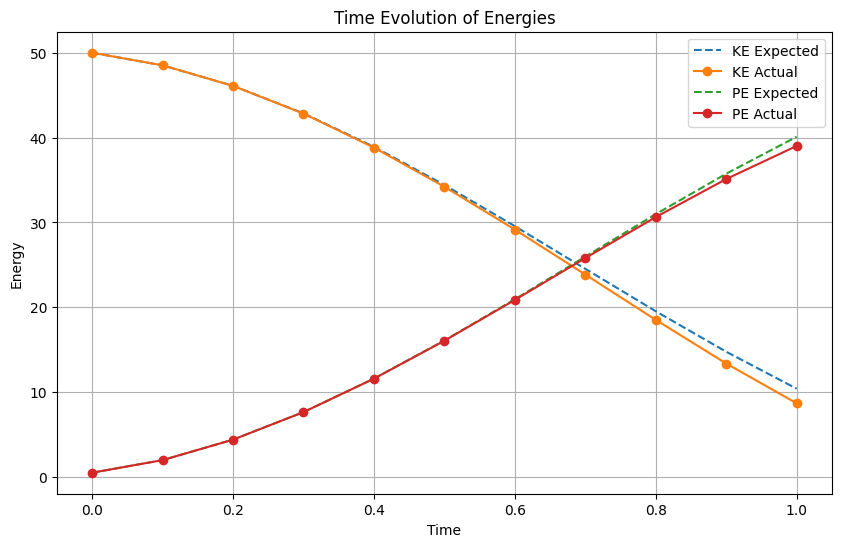

In [16]:
case = df[(df['y0'] == 1) & (df['vy0'] == 10) & (df['k'] == 3) & (df['bx'] == 0.0) & (df['by'] == 0.0)]

plt.figure(figsize=(10, 6))
plt.plot(case['t'], case['kinetic_expected'], label='KE Expected', linestyle='--')
plt.plot(case['t'], case['kinetic_actual'], label='KE Actual', marker='o')
plt.plot(case['t'], case['potential_expected'], label='PE Expected', linestyle='--')
plt.plot(case['t'], case['potential_actual'], label='PE Actual', marker='o')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Time Evolution of Energies')
plt.legend()
plt.grid(True)
plt.show()

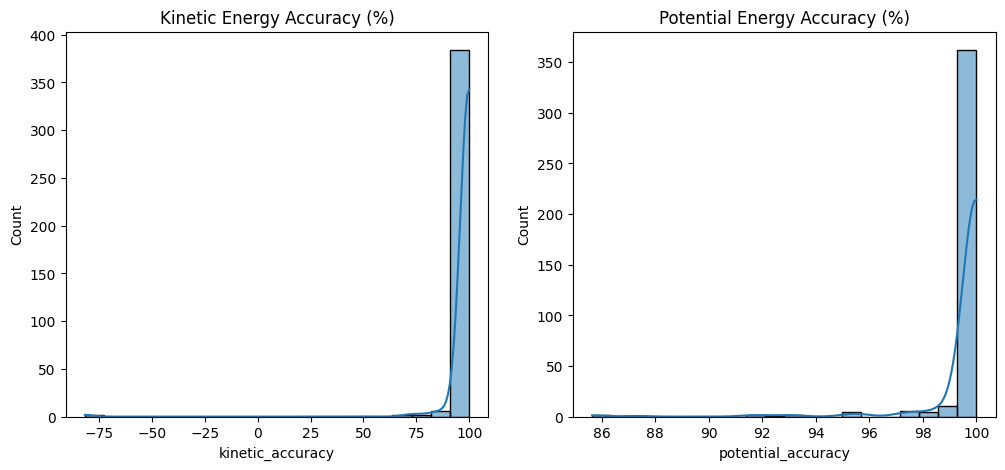

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['kinetic_accuracy'], bins=20, kde=True)
plt.title('Kinetic Energy Accuracy (%)')

plt.subplot(1, 2, 2)
sns.histplot(df['potential_accuracy'], bins=20, kde=True)
plt.title('Potential Energy Accuracy (%)')

plt.show()

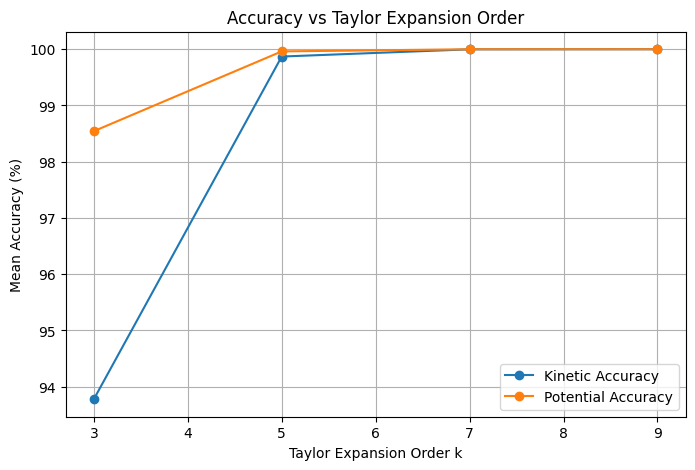

In [18]:
accuracy_summary = df.groupby('k')[['kinetic_accuracy', 'potential_accuracy']].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(accuracy_summary['k'], accuracy_summary['kinetic_accuracy'], marker='o', label='Kinetic Accuracy')
plt.plot(accuracy_summary['k'], accuracy_summary['potential_accuracy'], marker='o', label='Potential Accuracy')
plt.xlabel('Taylor Expansion Order k')
plt.ylabel('Mean Accuracy (%)')
plt.title('Accuracy vs Taylor Expansion Order')
plt.grid(True)
plt.legend()
plt.show()